In [1]:
import netCDF4 as nc 
import matplotlib.pyplot as plt
import numpy as np
import itertools
import xarray as xr
import glob
from pathlib import Path
import torch
import patcher
import pandas as pd

In [2]:
DATA_DIR = Path('/Volumes/portable/arpp/data')
patcher_context = patcher.Context(str(DATA_DIR), 16)

In [3]:
ALL_VARS = [f.stem for f in list(DATA_DIR.glob('*.bin'))]
INM_VARS = [v for v in ALL_VARS if v.split("_")[0] == 'inm']
ERA_VARS = [v for v in ALL_VARS if v.split("_")[0] != 'inm']
ERA_VARS.remove('config')
print(f"ERA_VARS:\n {' / '.join(ERA_VARS)}")
print(f"INM_VARS:\n {' / '.join(INM_VARS)}")

ERA_VARS:
 z_log / glaicer / snow_cover / sd / sst / t2m / tp / sden / snow_cover_log / z / sdor_log / sd_log / sdor / lsm / tp_log / pt
INM_VARS:
 inm_swe / inm_ts / inm_swe_log / inm_mslp / inm_tp / inm_u850 / inm_tp_log / inm_snow_cover / inm_ww_log / inm_olr / inm_h500 / inm_hlt / inm_ww / inm_v850 / inm_t2m


#### **Dataset**


 load climate keys: ['hist_sd_log_6weeks', 'hist_sd_log_6months', 'hist_sden_6weeks', 'hist_sden_6months', 'inm_ww_log_17weeks', 'target_sd_log_17weeks'] 



 NORMED DATASET:<_io.TextIOWrapper name='database/norms/Contigous_Russia_Dataset/Contigous_Russia_Dataset.json' mode='r' encoding='utf-8'>



 load climate keys: ['hist_sd_log_6weeks', 'hist_sd_log_6months', 'hist_sden_6weeks', 'hist_sden_6months', 'inm_ww_log_17weeks', 'target_sd_log_17weeks'] 



 NORMED DATASET:<_io.TextIOWrapper name='database/norms/Contigous_Russia_Dataset/Contigous_Russia_Dataset.json' mode='r' encoding='utf-8'>


hist_snow_cover_6weeks: torch.Size([6, 177, 717])
hist_snow_cover_6months: torch.Size([6, 177, 717])
hist_sd_log_6weeks: torch.Size([6, 177, 717])
hist_sd_log_6months: torch.Size([6, 177, 717])
hist_sst_6weeks: torch.Size([6, 177, 717])
hist_sst_6months: torch.Size([6, 177, 717])
hist_t2m_6weeks: torch.Size([6, 177, 717])
hist_t2m_6months: torch.Size([6, 177, 717])
hist_tp_log_6weeks: torch.Size([

/var/folders/zj/llz5pnt12dqgd3j4hf1bw7_m0000gn/T/ipykernel_2105/809997169.py:67: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5),  gridspec_kw={'width_ratios': [2, 1, 1]}, constrained_layout=True)


inm_t2m_17weeks: torch.Size([10, 17, 45, 180])
target_sd_log_17weeks: torch.Size([17, 177, 717])
target_snow_cover_17weeks: torch.Size([17, 177, 717])
surf_z: torch.Size([1, 177, 717])
surf_sdor: torch.Size([1, 177, 717])
surf_lsm: torch.Size([1, 177, 717])
surf_glaicer: torch.Size([1, 177, 717])
inm_lead_time_17weeks: torch.Size([17])
valid_doy_sin_17weeks: torch.Size([17])
valid_doy_cos_17weeks: torch.Size([17])
lat_era: torch.Size([177])
lon_era: torch.Size([717])
target_sd_log_17weeks_mask: torch.Size([17, 177, 717])
target_snow_cover_17weeks_mask: torch.Size([1, 177, 717])


 One instance size: 108.0 MB 




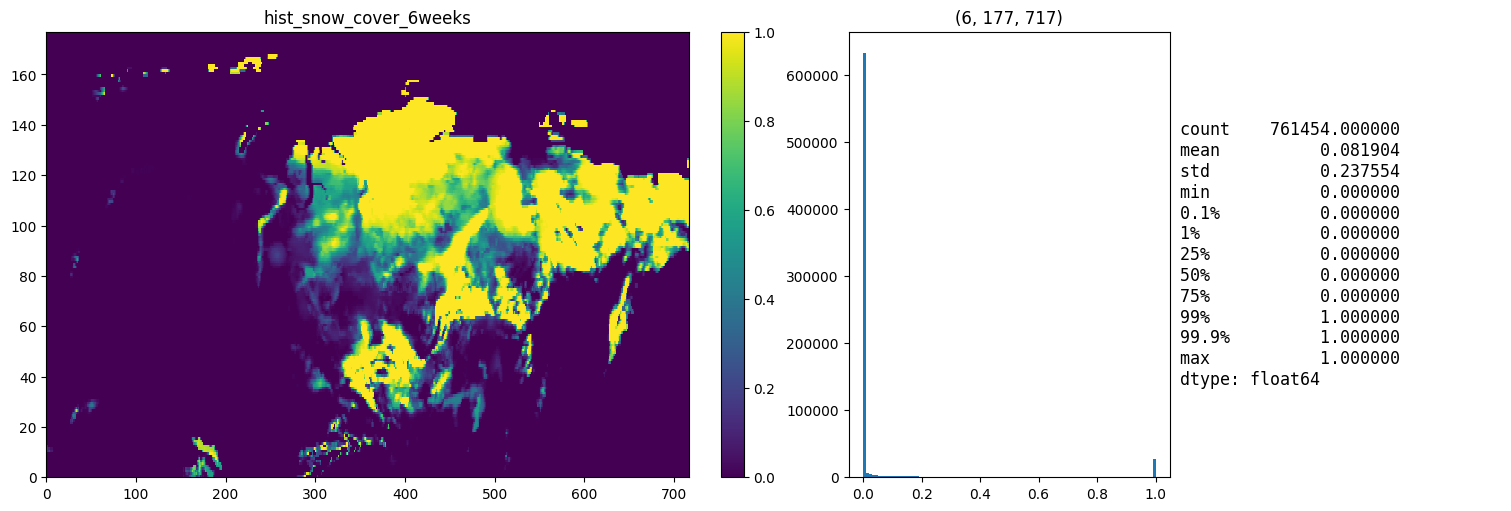

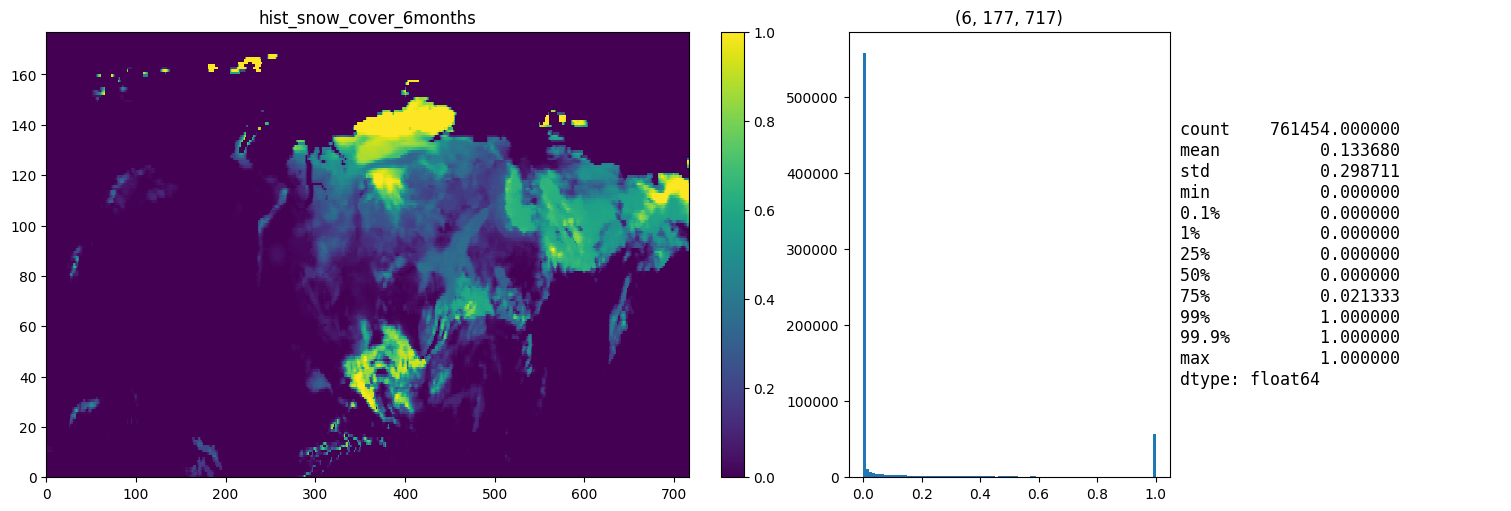

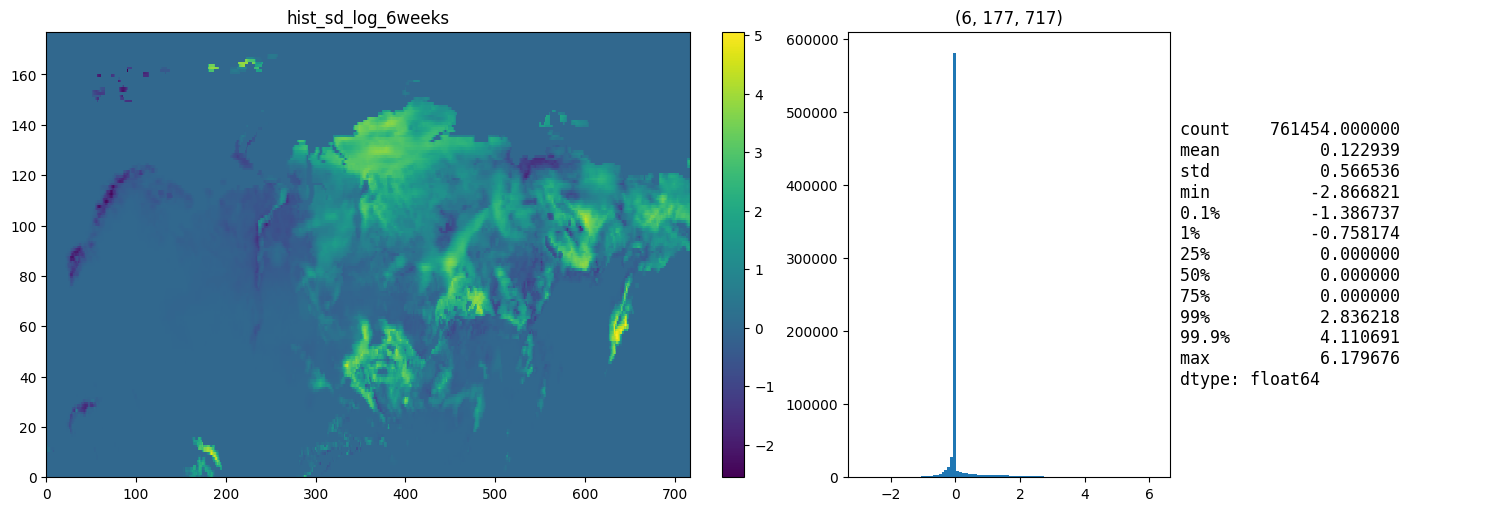

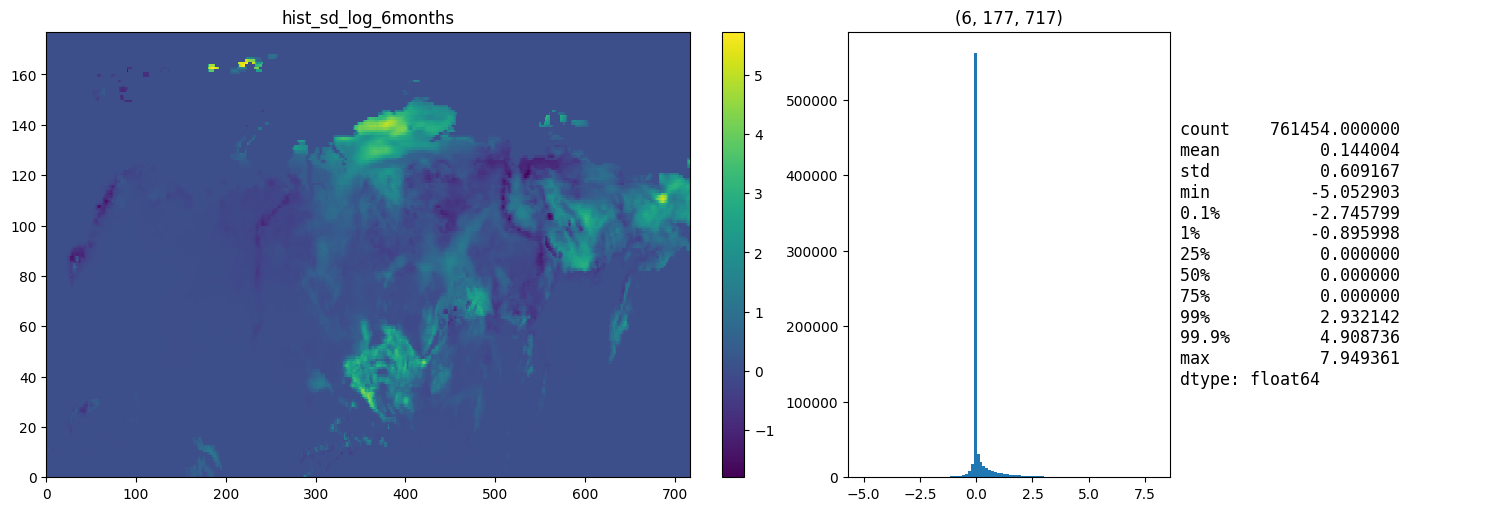

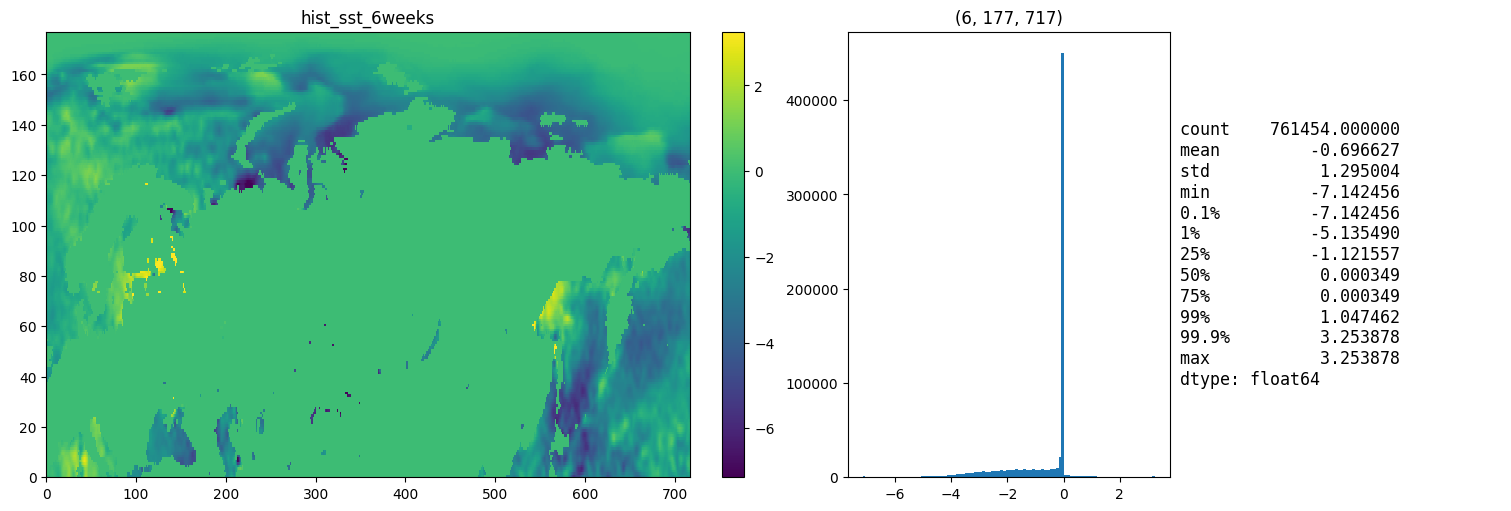

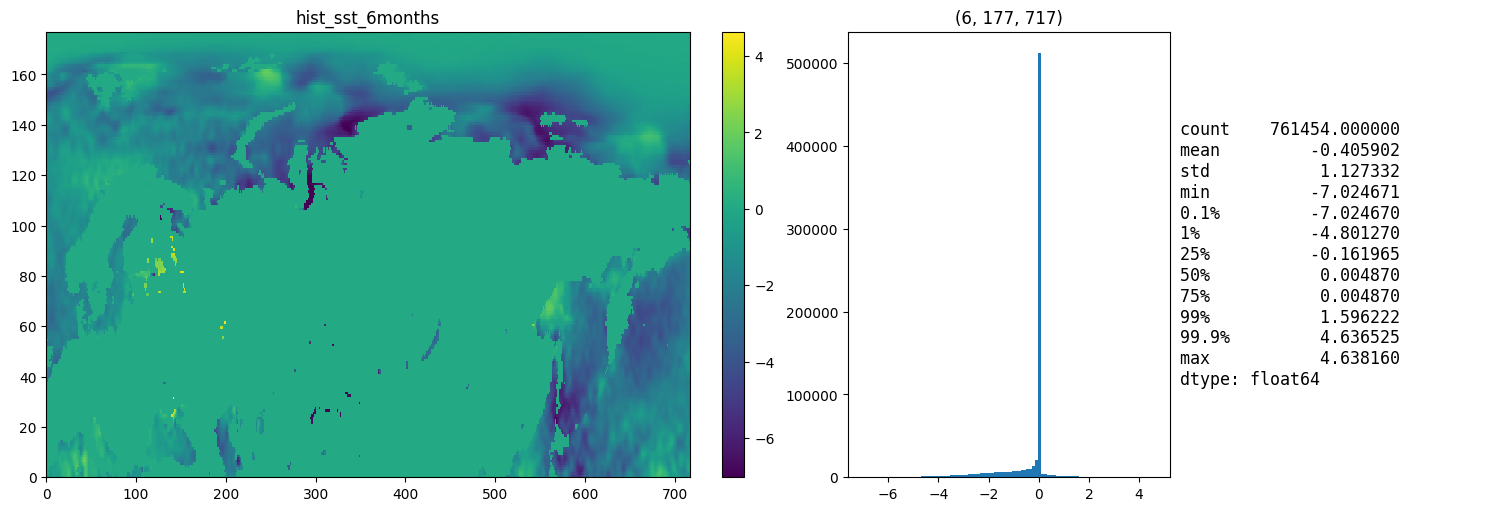

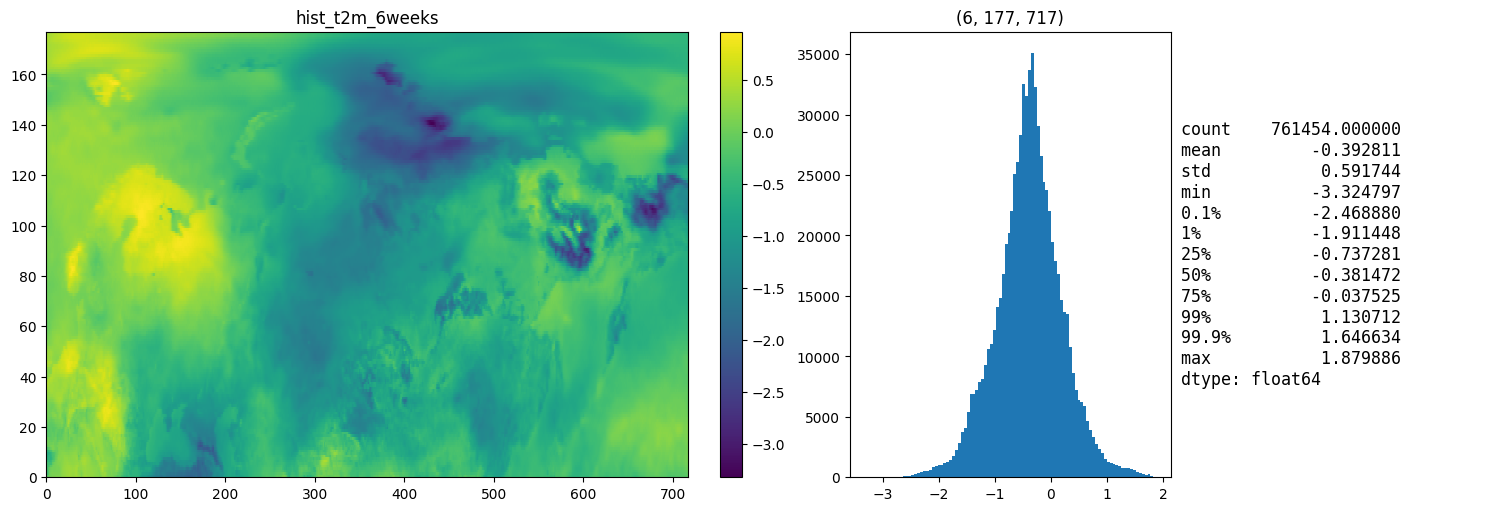

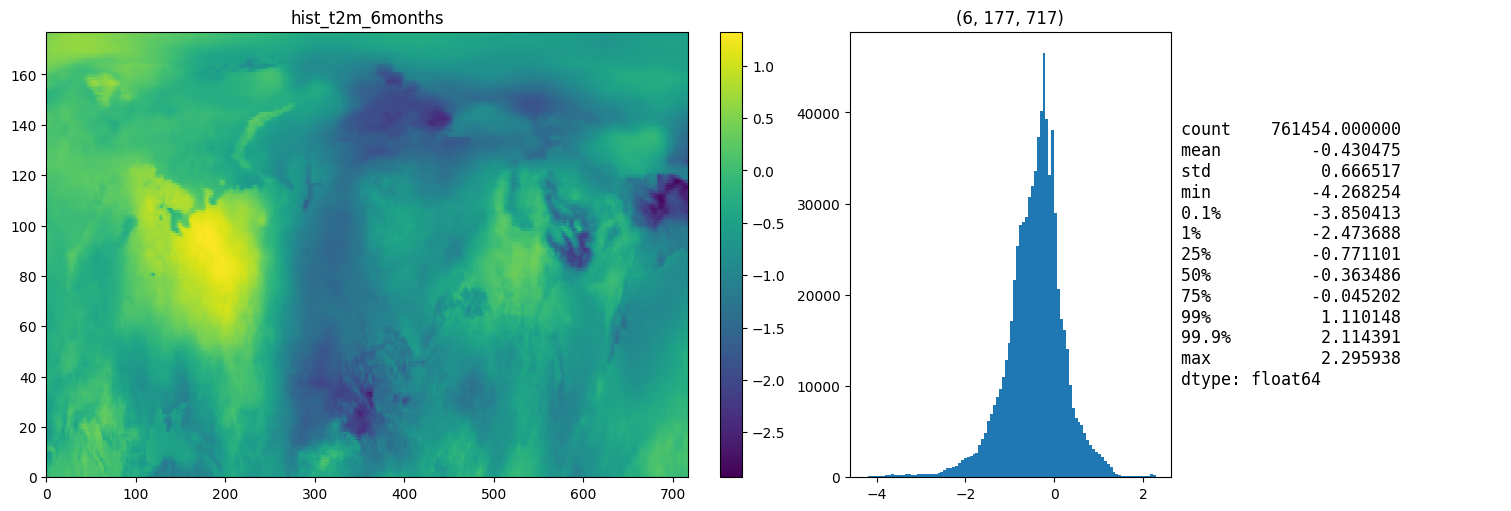

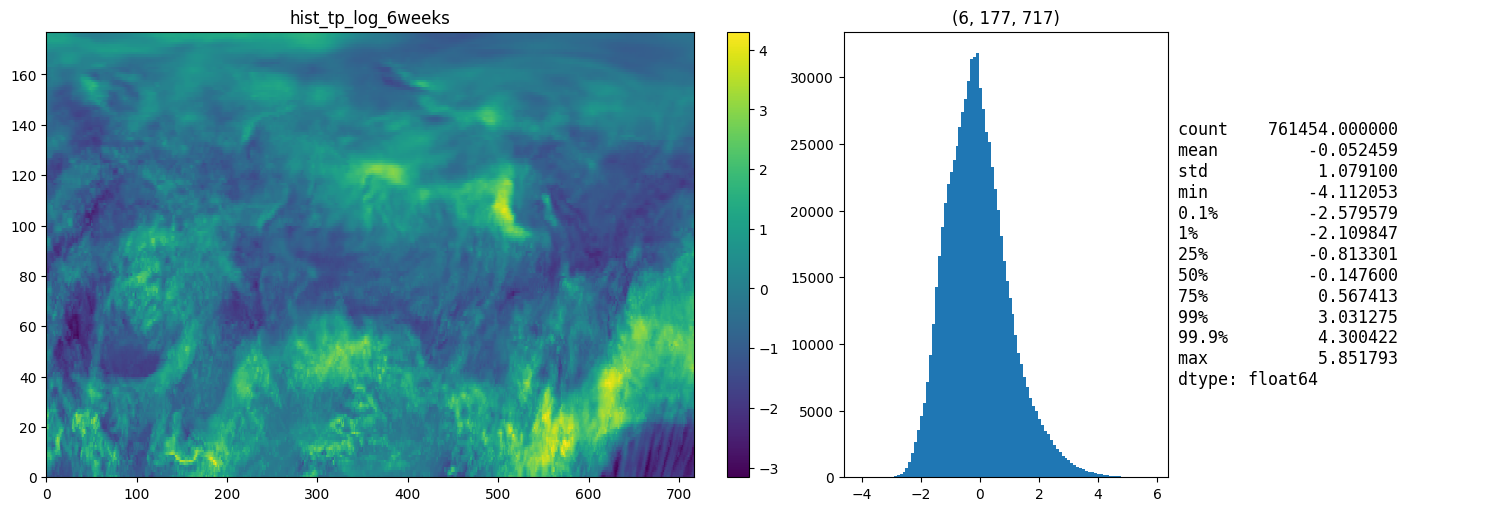

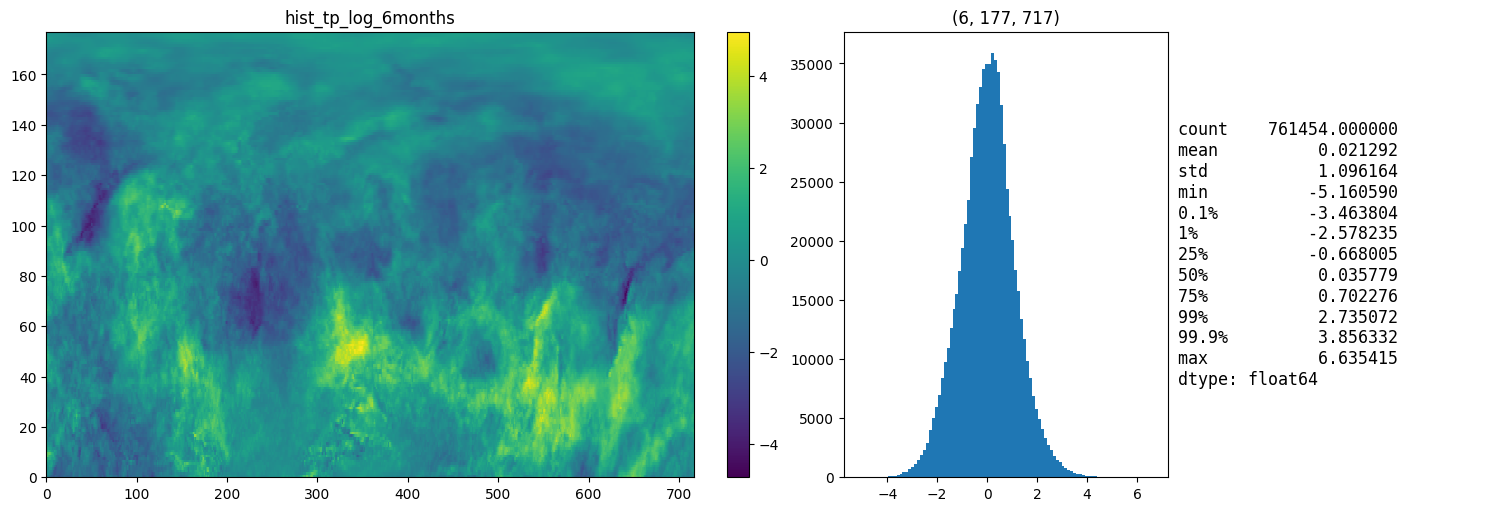

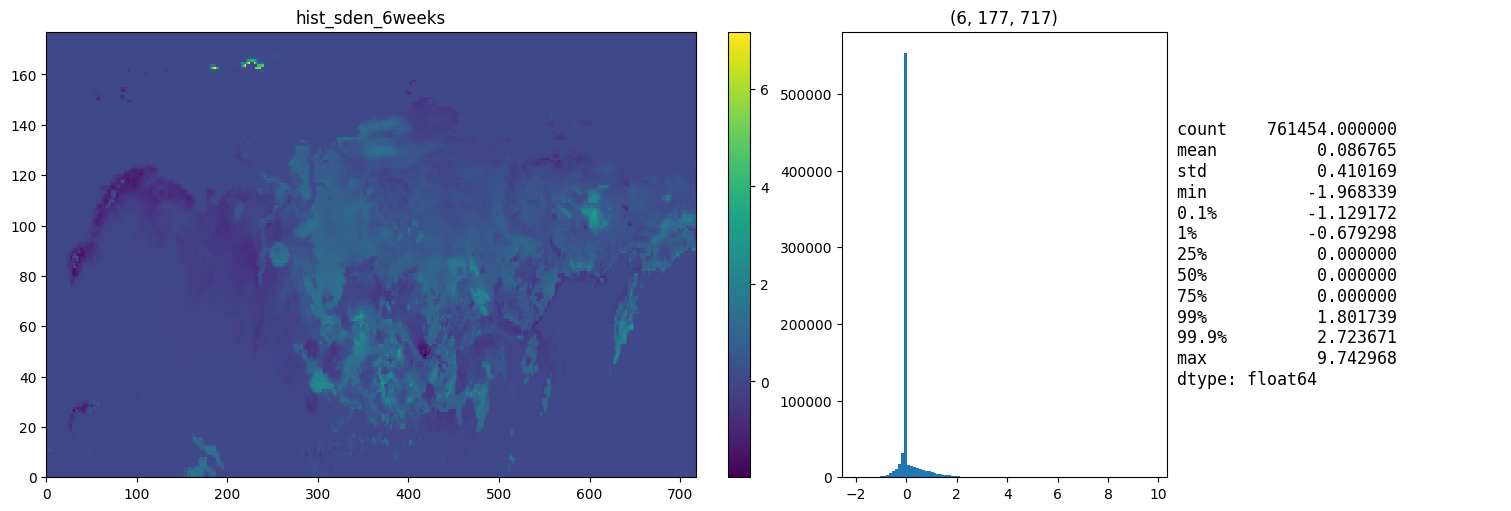

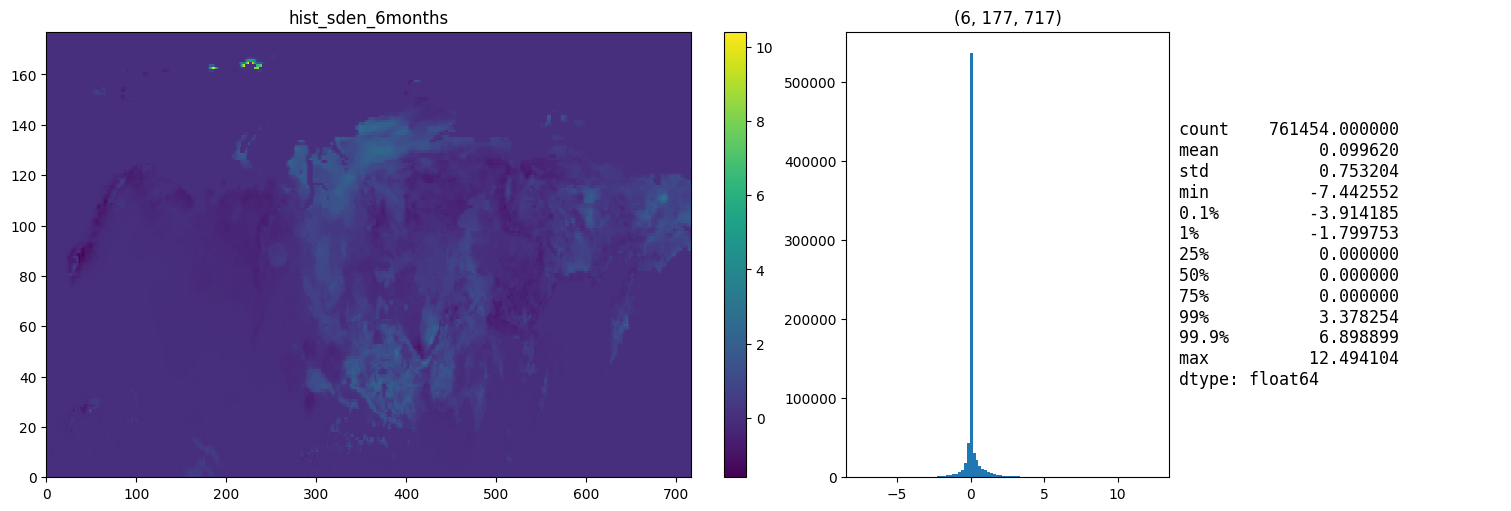

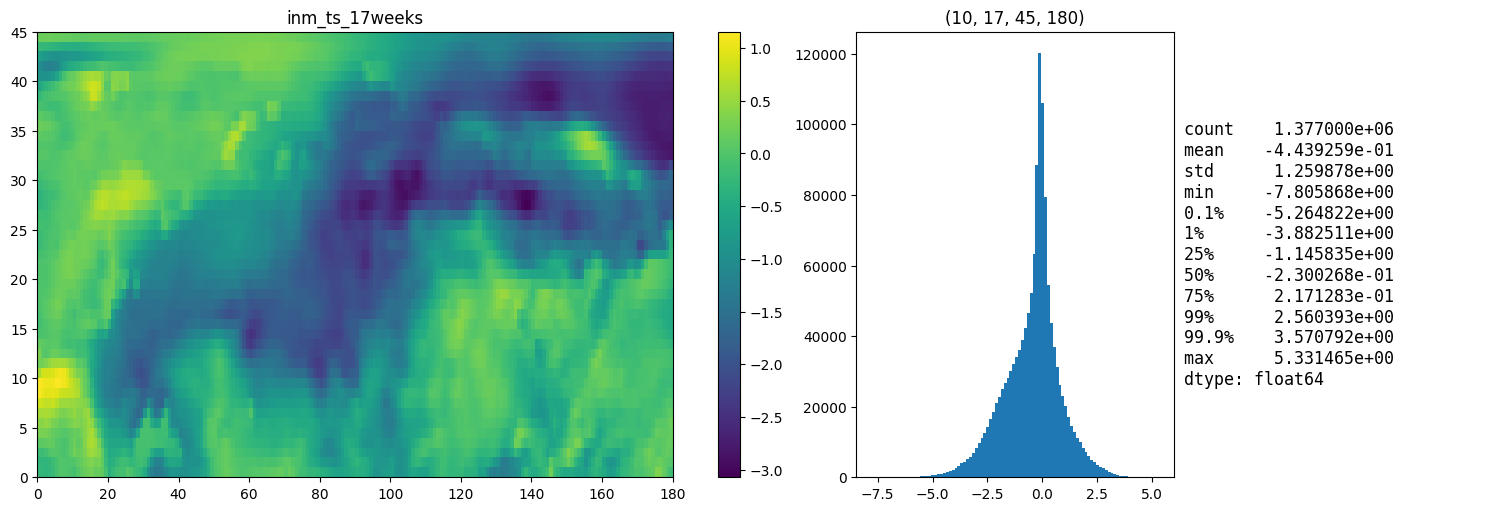

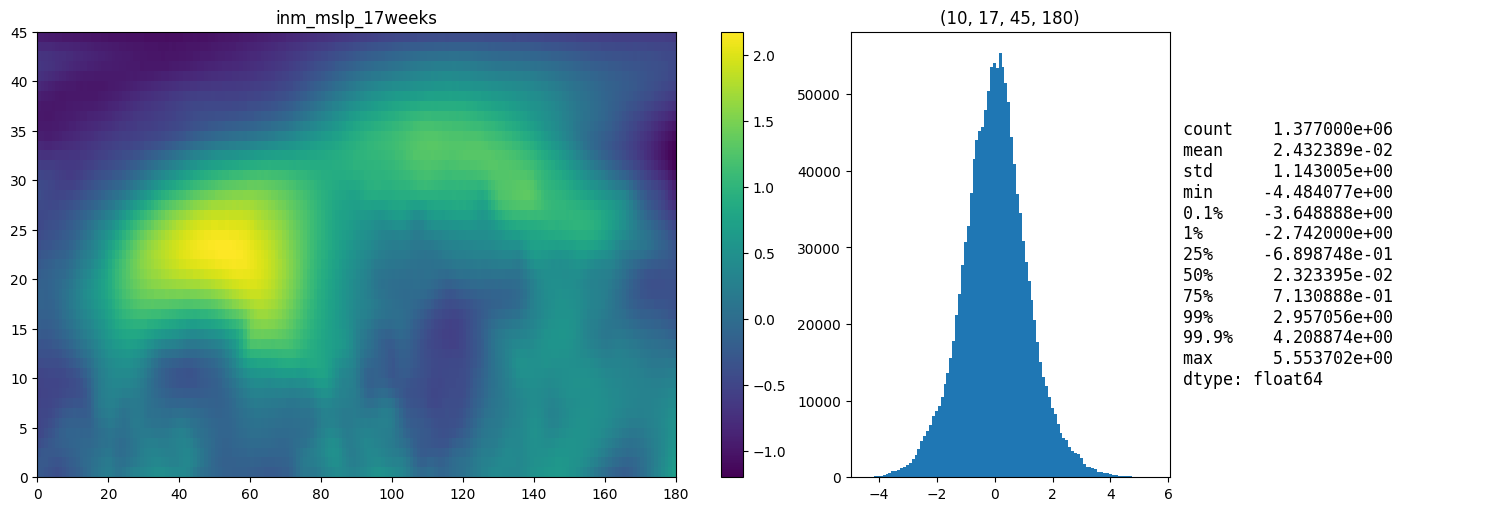

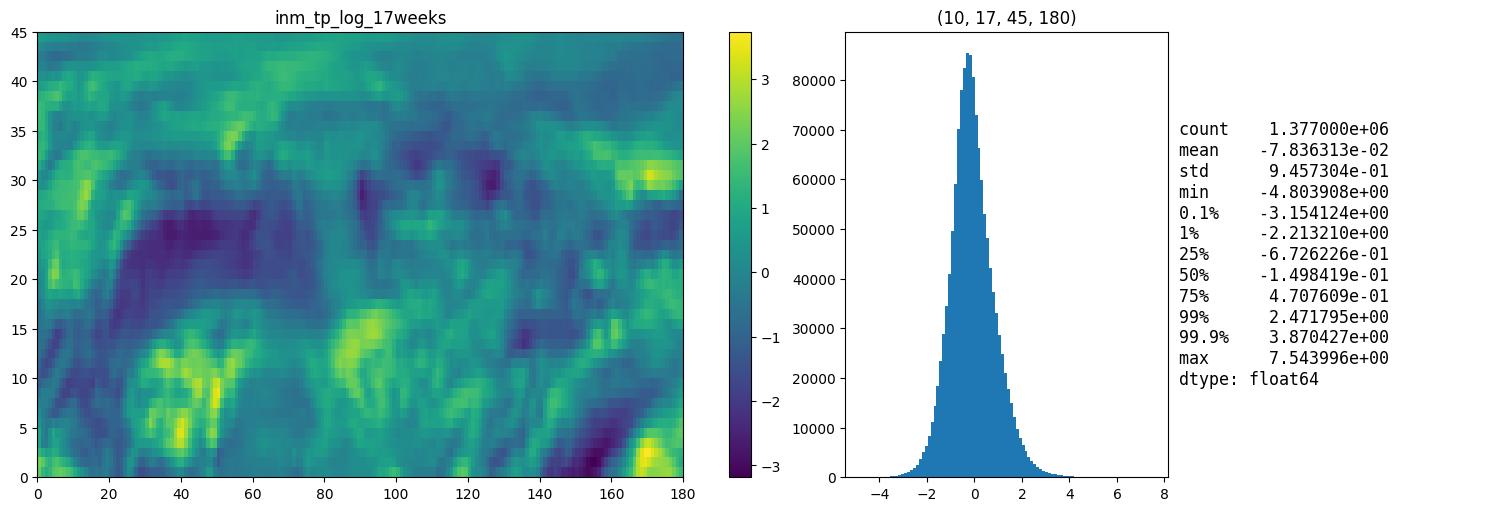

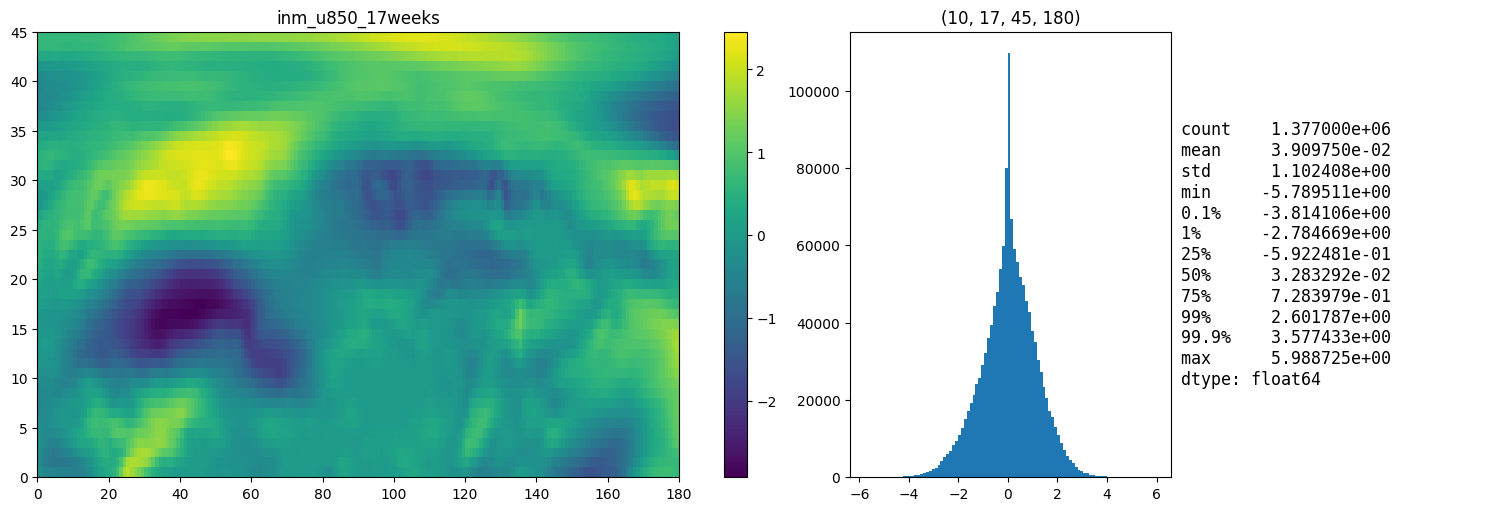

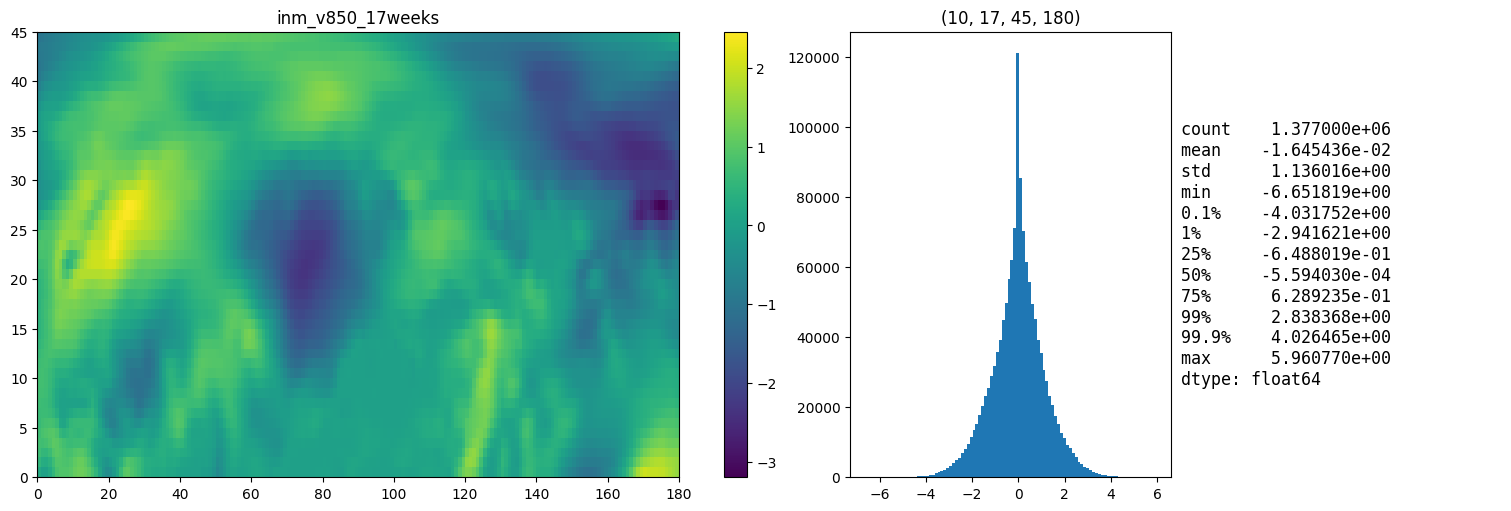

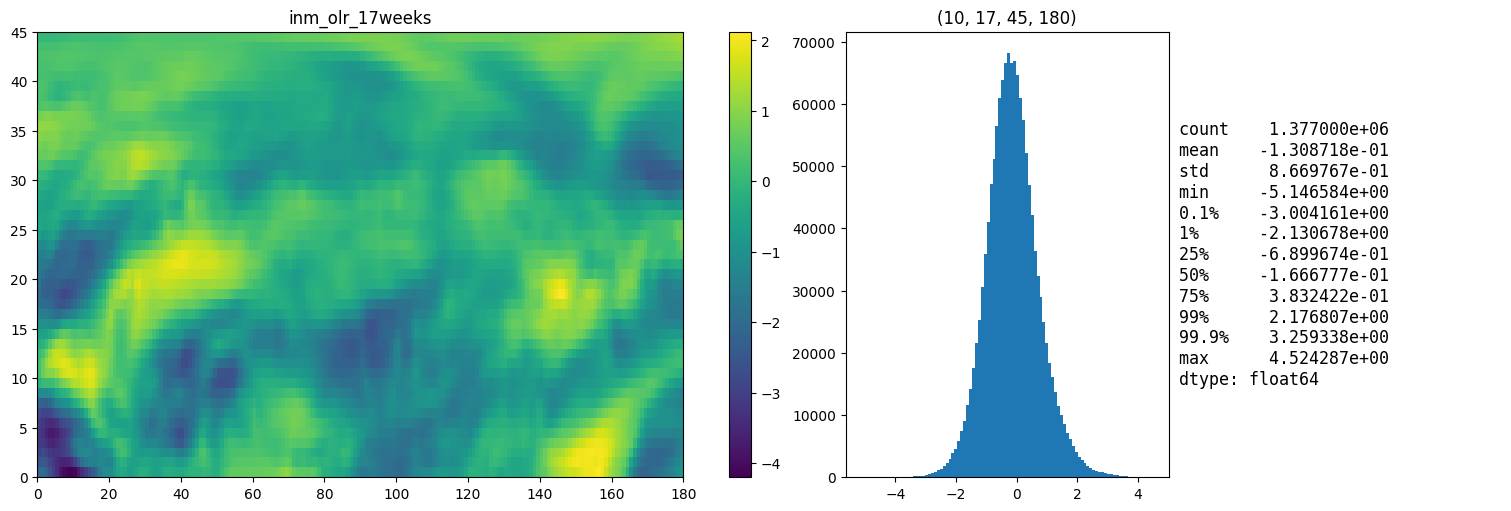

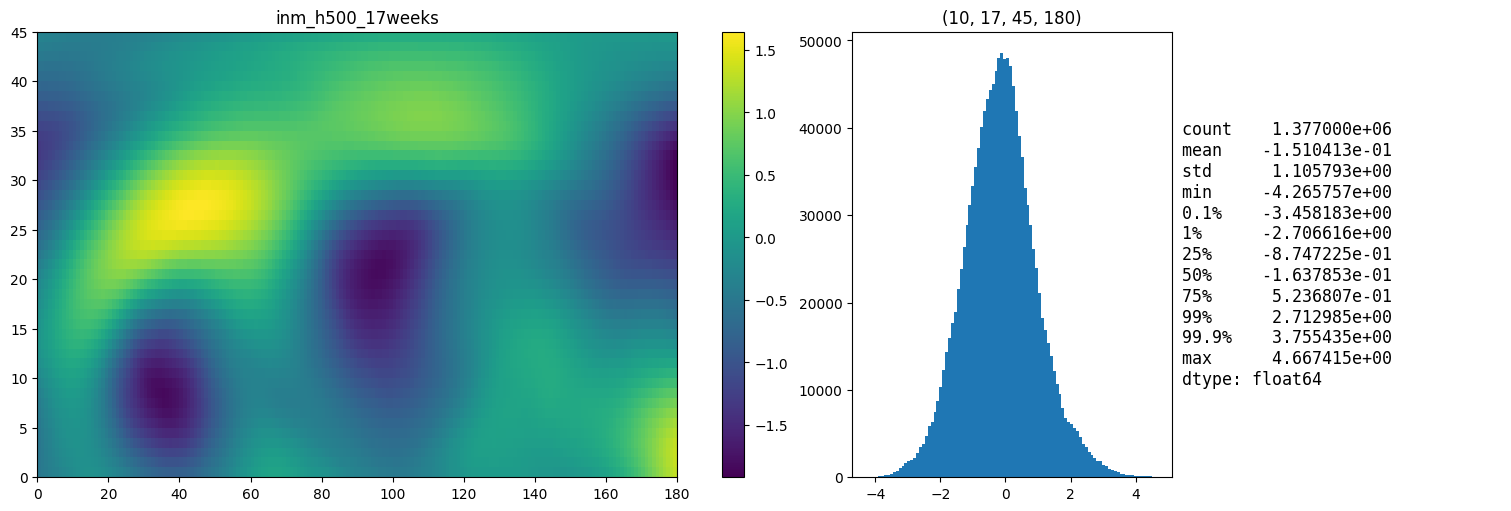

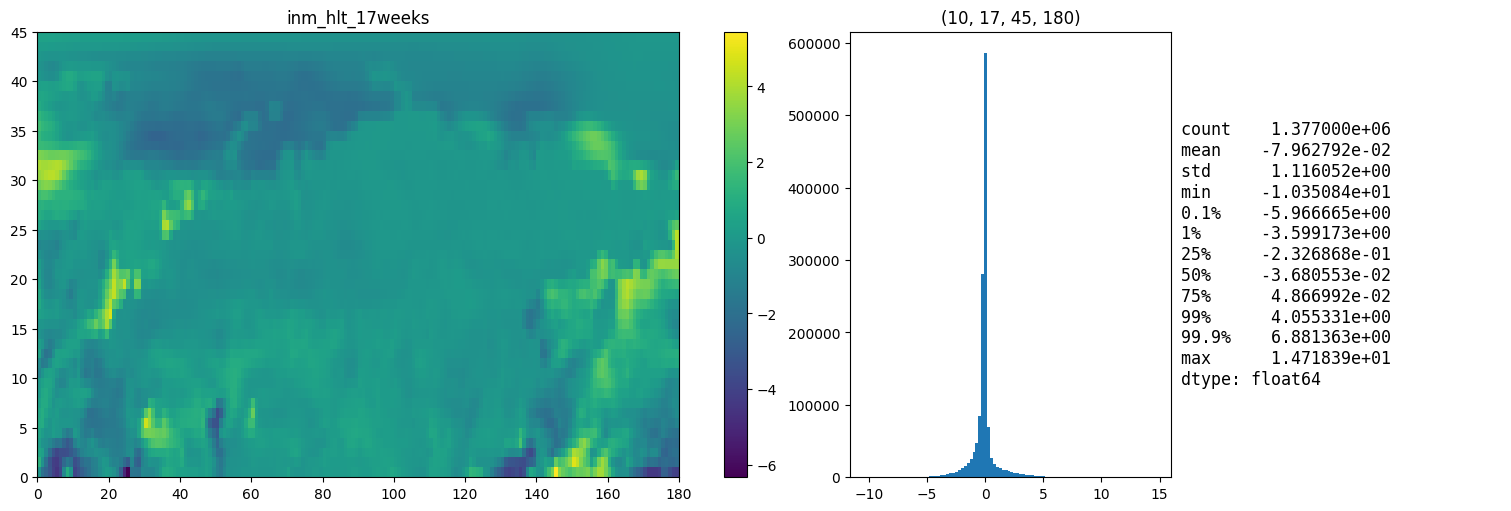

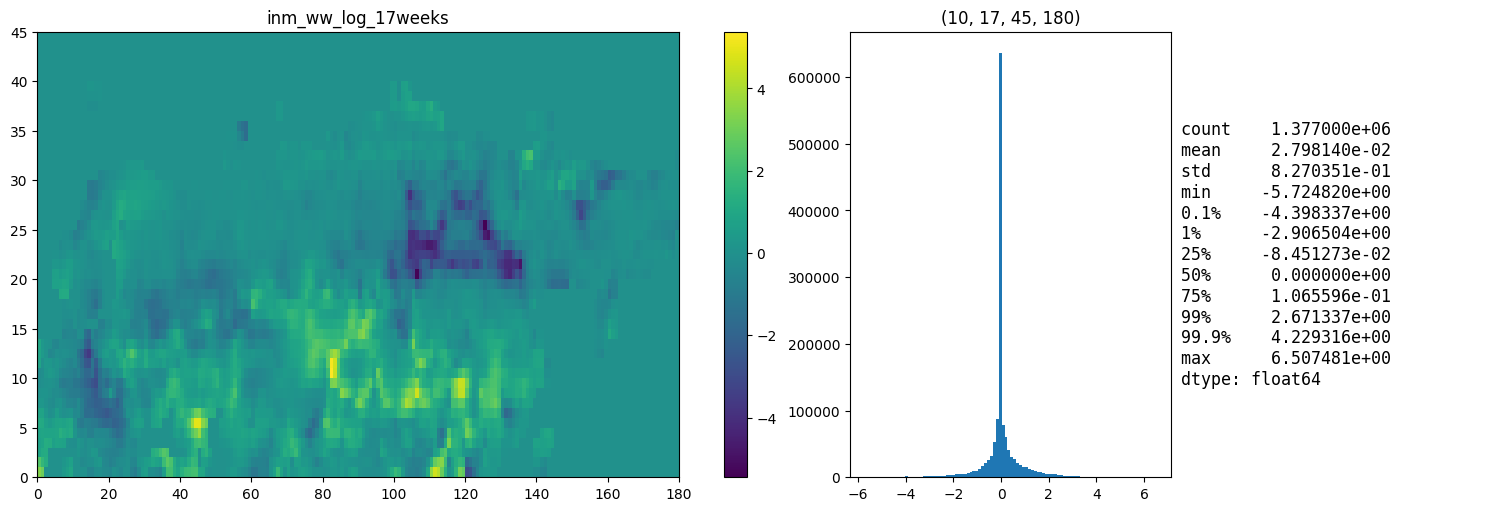

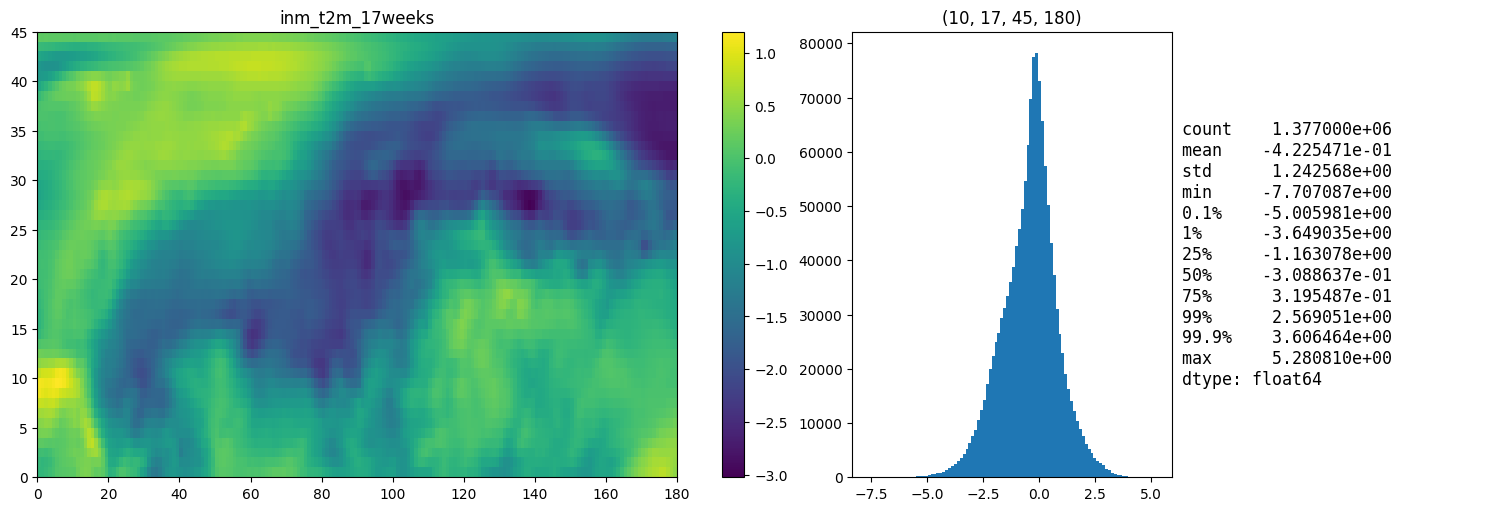

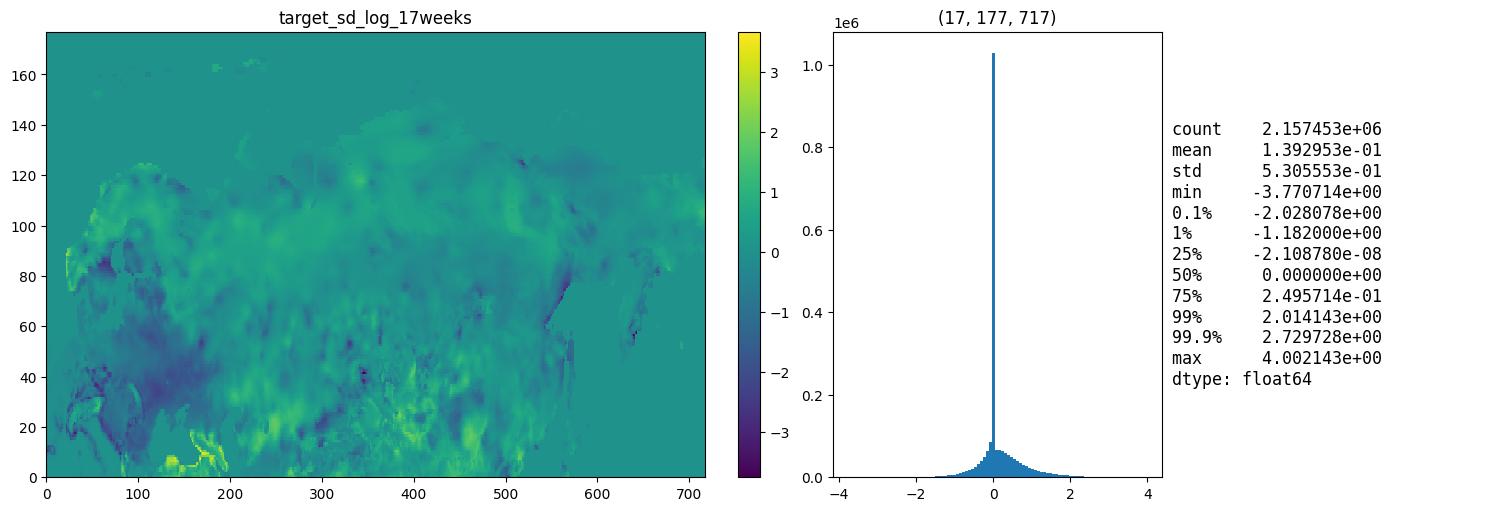

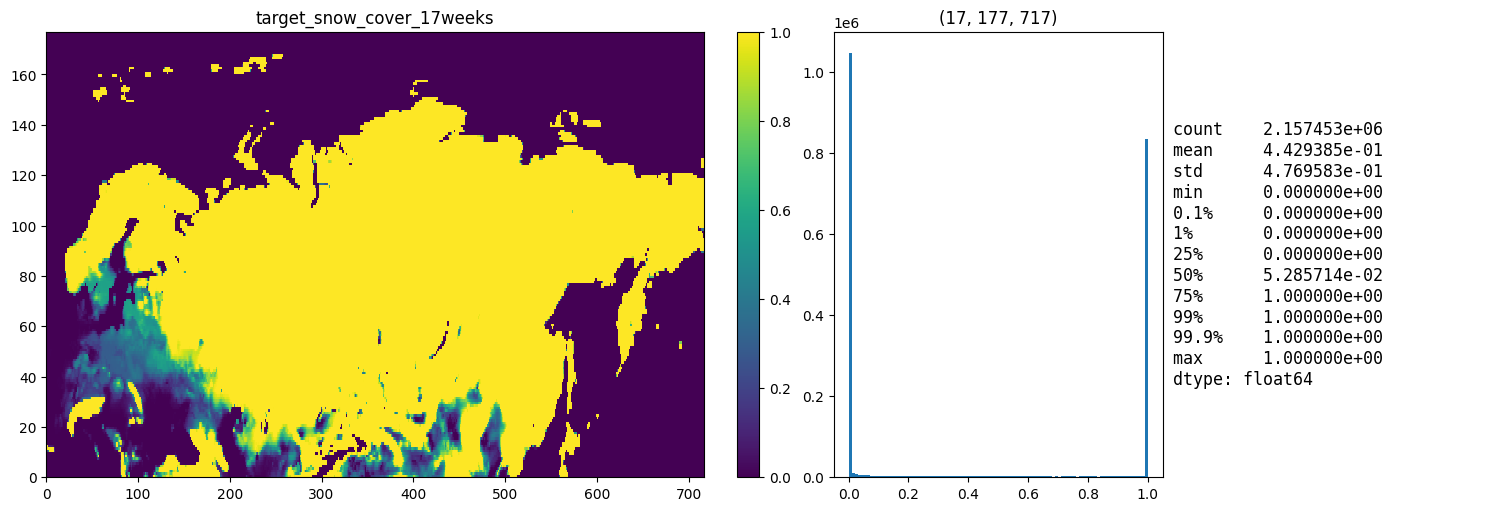

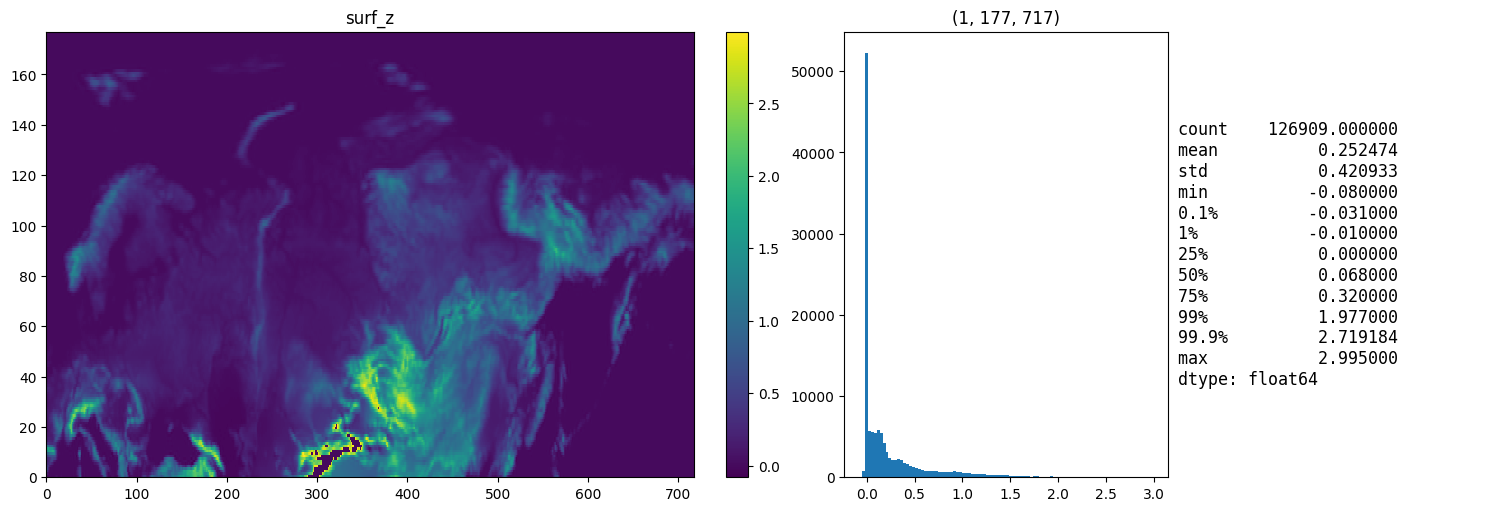

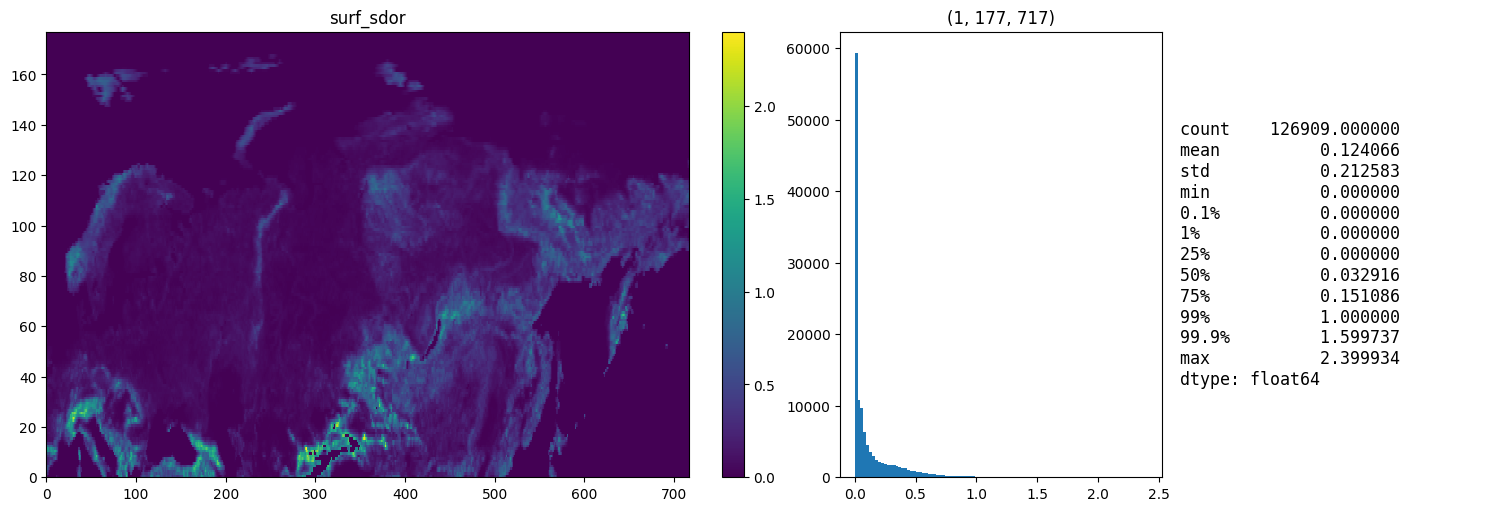

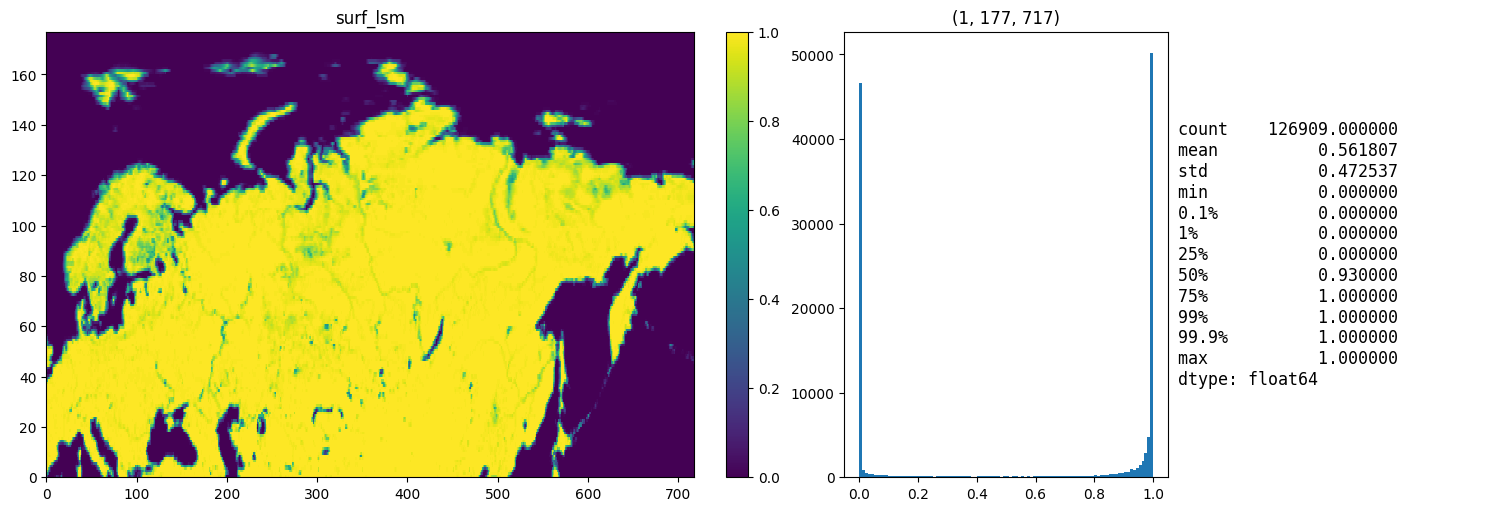

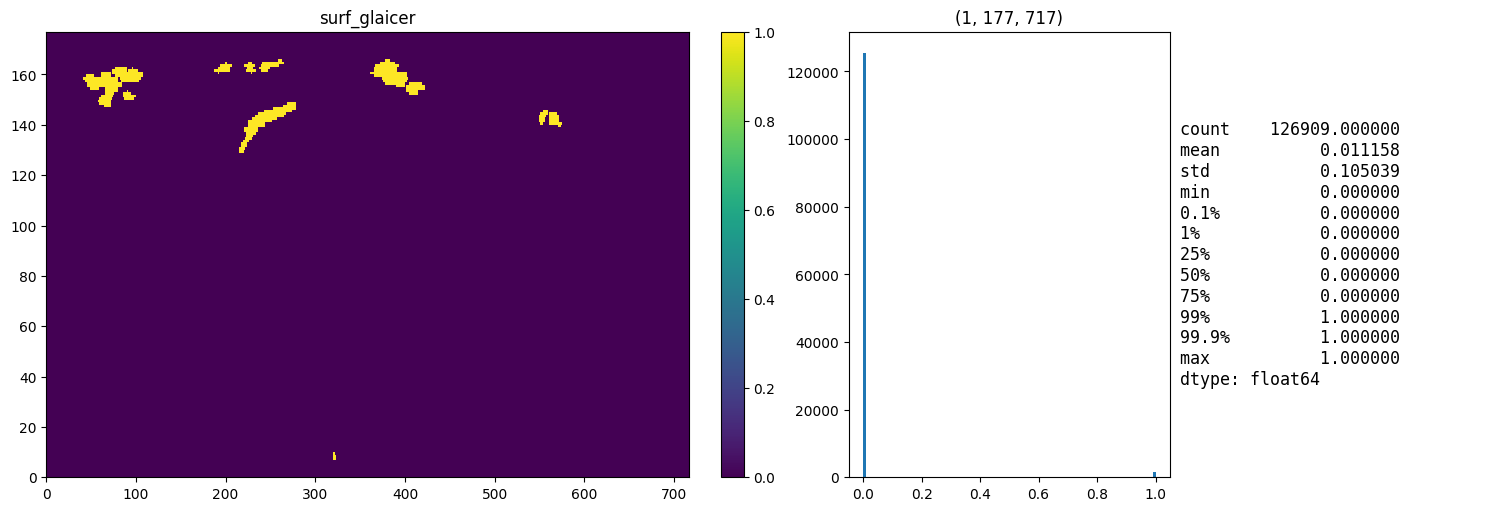

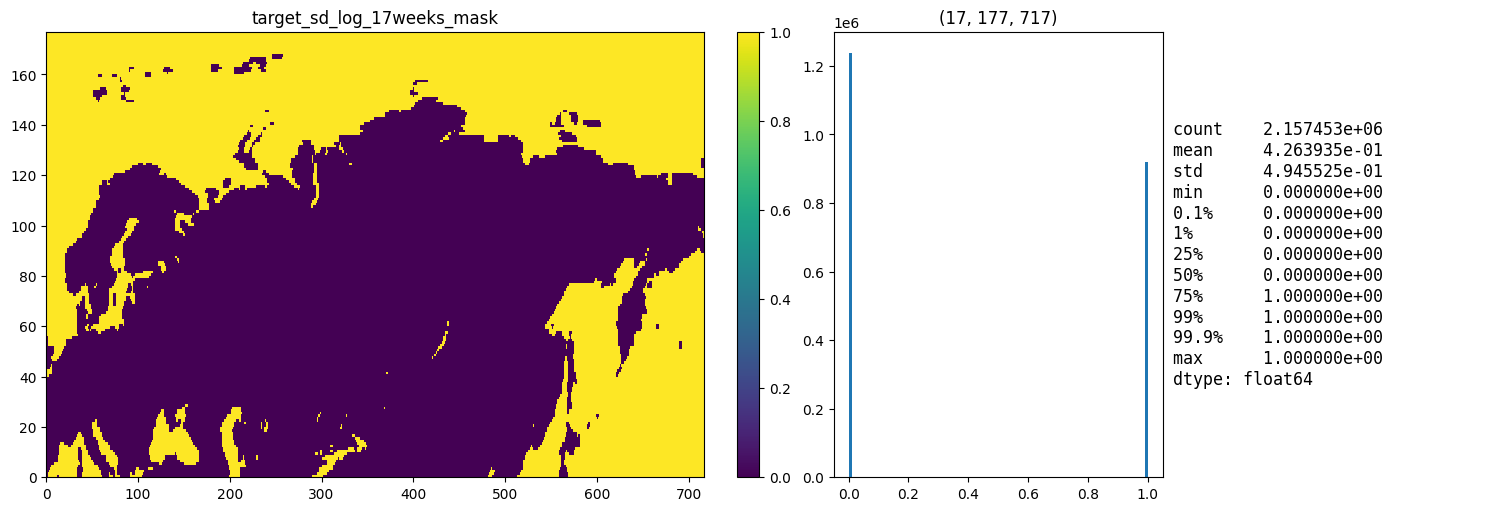

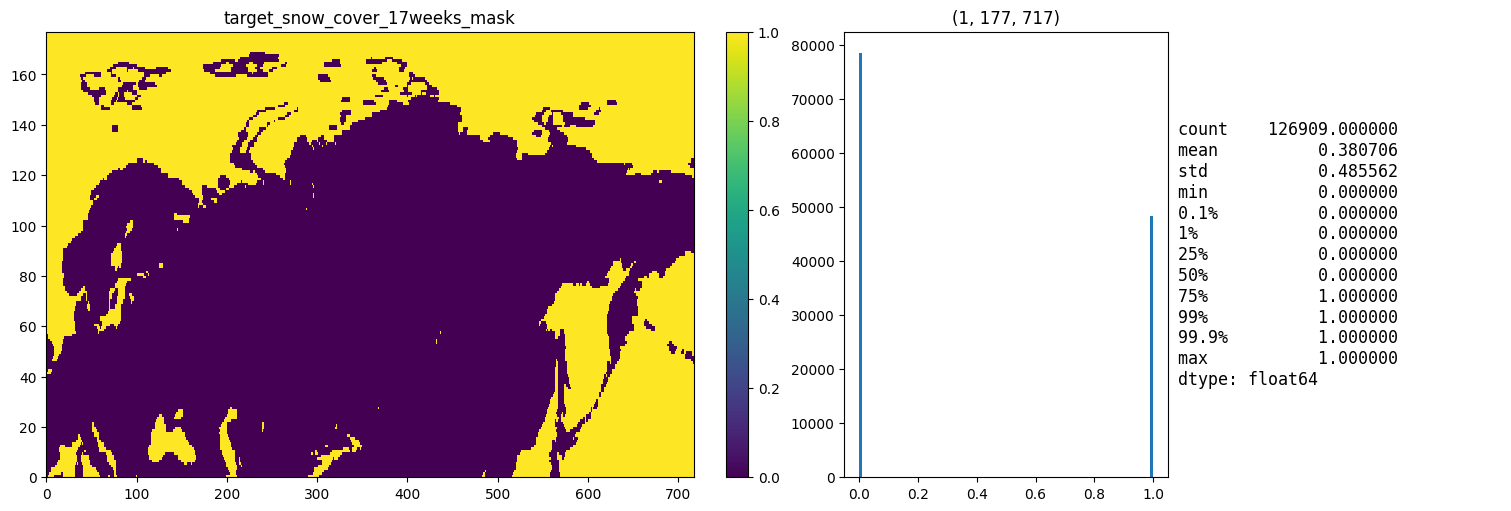

In [4]:
from scripts.utils import ContiguousDataset
from matplotlib import pyplot as plt

# {id: {var, tStep, tSize}}. id prefix -> branch: hist | inm | target | surf

features = {
    'hist_snow_cover_6weeks':      {'var': 'snow_cover',    'tStep': 7 , 'tSize': 6},
    'hist_snow_cover_6months':     {'var': 'snow_cover',    'tStep': 30, 'tSize': 6},
    'hist_sd_log_6weeks':          {'var': 'sd_log',        'tStep': 7 , 'tSize': 6},   #!
    'hist_sd_log_6months':         {'var': 'sd_log',        'tStep': 30, 'tSize': 6},   #!
    'hist_sst_6weeks':             {'var': 'sst',           'tStep': 7 , 'tSize': 6},
    'hist_sst_6months':            {'var': 'sst',           'tStep': 30, 'tSize': 6},
    'hist_t2m_6weeks':             {'var': 't2m',           'tStep': 7 , 'tSize': 6},
    'hist_t2m_6months':            {'var': 't2m',           'tStep': 30, 'tSize': 6},
    'hist_tp_log_6weeks':          {'var': 'tp_log',        'tStep': 7 , 'tSize': 6},   #!
    'hist_tp_log_6months':         {'var': 'tp_log',        'tStep': 30, 'tSize': 6},   #!
    'hist_sden_6weeks':            {'var': 'sden',          'tStep': 7 , 'tSize': 6},
    'hist_sden_6months':           {'var': 'sden',          'tStep': 30, 'tSize': 6},
    #'hist_pt_6weeks':              {'var': 'pt',            'tStep': 7 , 'tSize': 6},   #!
    #'hist_pt_6months':             {'var': 'pt',            'tStep': 30, 'tSize': 6},   #!

    #'inm_swe_log_17weeks':         {'var': 'inm_swe_log',   'tStep': 7 , 'tSize': 17},
    'inm_ts_17weeks':              {'var': 'inm_ts',        'tStep': 7 , 'tSize': 17},
    'inm_mslp_17weeks':            {'var': 'inm_mslp',      'tStep': 7 , 'tSize': 17},
    'inm_tp_log_17weeks':          {'var': 'inm_tp_log',    'tStep': 7 , 'tSize': 17},   #!
    'inm_u850_17weeks':            {'var': 'inm_u850',      'tStep': 7 , 'tSize': 17},
    'inm_v850_17weeks':            {'var': 'inm_v850',      'tStep': 7 , 'tSize': 17},
    #'inm_snow_cover_17weeks':      {'var': 'inm_snow_cover','tStep': 7 , 'tSize': 17},
    'inm_olr_17weeks':             {'var': 'inm_olr',       'tStep': 7 , 'tSize': 17},
    'inm_h500_17weeks':            {'var': 'inm_h500',      'tStep': 7 , 'tSize': 17},
    'inm_hlt_17weeks':             {'var': 'inm_hlt',       'tStep': 7 , 'tSize': 17},
    'inm_ww_log_17weeks':          {'var': 'inm_ww_log',    'tStep': 7 , 'tSize': 17},   #!
    'inm_t2m_17weeks':             {'var': 'inm_t2m',       'tStep': 7 , 'tSize': 17},

    'surf_z':                      {'var': 'z'},
    'surf_sdor':                   {'var': 'sdor'},
    'surf_lsm':                    {'var': 'lsm'},
    'surf_glaicer':                {'var': 'glaicer'},

    'target_sd_log_17weeks':       {'var': 'sd_log',        'tStep': 7 , 'tSize': 17},
    'target_snow_cover_17weeks':   {'var': 'snow_cover',    'tStep': 7 , 'tSize': 17},
}

inm_bbox = {'x0':180, 'y0':40, 'xSize':180, 'ySize':45}
era_bbox = {'x0':180*4, 'y0':40*4, 'xSize':(180*4)-3, 'ySize':(45*4)-3}
features = {k:v|inm_bbox if k.startswith('inm_') else v|era_bbox for k,v in features.items()}

load_climate = ('hist_sd', 'hist_sden', 'inm_ww', 'target_sd')

train_dates = pd.date_range('19910201', '20210101', freq='MS').strftime('%Y%m%d')
test_dates = pd.date_range('20240901', '20260201', freq='MS').strftime('%Y%m%d')

train_ds = ContiguousDataset(features=features, dates=train_dates, load_climate=load_climate, name = 'Contigous_Russia_Dataset')
test_ds = ContiguousDataset(features=features, dates=test_dates, load_climate=load_climate, name = 'Contigous_Russia_Dataset')

#idx = list(test_dates).index('20241001')
idx = list(train_dates).index('19921001')
#instnc = test_ds[idx]
instnc = train_ds[idx]

for key, tensor in instnc.items():
    print(f'{key}: {tensor.shape}')
    if tensor.dim() < 2:            # lead_time / valid_doy / lat / lon -> 1D, not maps
        continue
    to_draw = tensor[0,0] if key.startswith('inm') and (not key.endswith('clim')) else tensor[-1]
    tensor = tensor.numpy().astype(float) if key.endswith('mask') else tensor.numpy()
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5),  gridspec_kw={'width_ratios': [2, 1, 1]}, constrained_layout=True)
    mesh = ax1.pcolormesh(to_draw)
    fig.colorbar(mesh, ax=ax1)
    ax1.set_title(key)
    ax2.hist(tensor.flatten(), bins=100)
    ax2.set_title(str(tensor.shape))
    desc = pd.Series(tensor.flatten()).describe(percentiles=[0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999])
    ax3.text(0, 0.5, str(desc), va='center', fontsize=12, family='monospace')
    ax3.axis('off')

total = sum(t.element_size() * t.nelement() for t in instnc.values())
print(f'\n\n One instance size: {total / 1024**2:.1f} MB \n\n')

#### Sanity-checks

In [9]:
list(instnc.keys())

['hist_snow_cover_6weeks',
 'hist_snow_cover_6months',
 'hist_sd_log_6weeks',
 'hist_sd_log_6months',
 'hist_sst_6weeks',
 'hist_sst_6months',
 'hist_t2m_6weeks',
 'hist_t2m_6months',
 'hist_tp_log_6weeks',
 'hist_tp_log_6months',
 'hist_sden_6weeks',
 'hist_sden_6months',
 'inm_ts_17weeks',
 'inm_mslp_17weeks',
 'inm_tp_log_17weeks',
 'inm_u850_17weeks',
 'inm_v850_17weeks',
 'inm_olr_17weeks',
 'inm_h500_17weeks',
 'inm_hlt_17weeks',
 'inm_ww_log_17weeks',
 'inm_t2m_17weeks',
 'target_sd_log_17weeks',
 'target_snow_cover_17weeks',
 'surf_z',
 'surf_sdor',
 'surf_lsm',
 'surf_glaicer',
 'inm_lead_time_17weeks',
 'valid_doy_sin_17weeks',
 'valid_doy_cos_17weeks',
 'lat_era',
 'lon_era',
 'lat_inm',
 'lon_inm',
 'target_sd_log_17weeks_mask',
 'target_snow_cover_17weeks_mask']

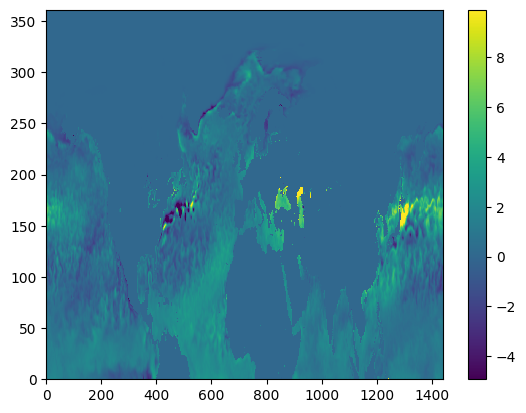

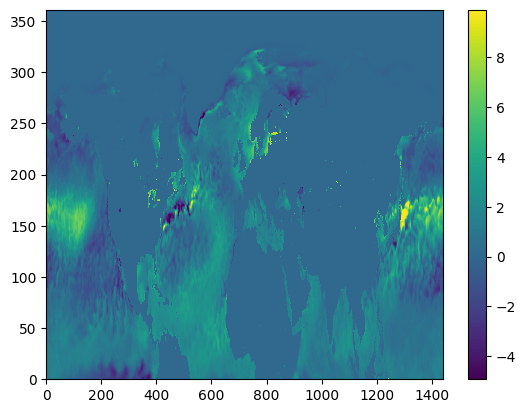

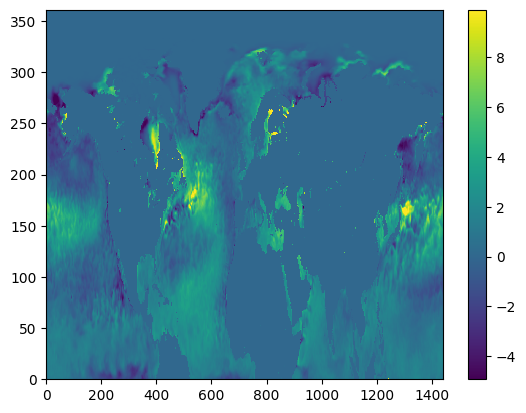

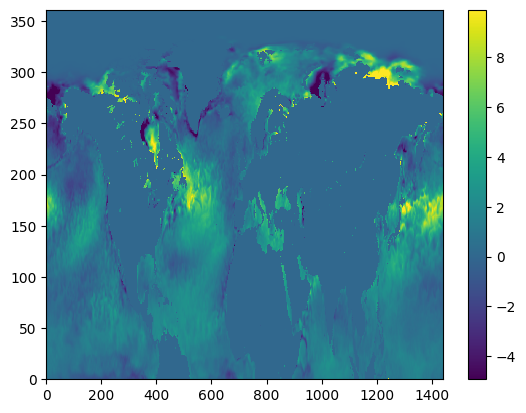

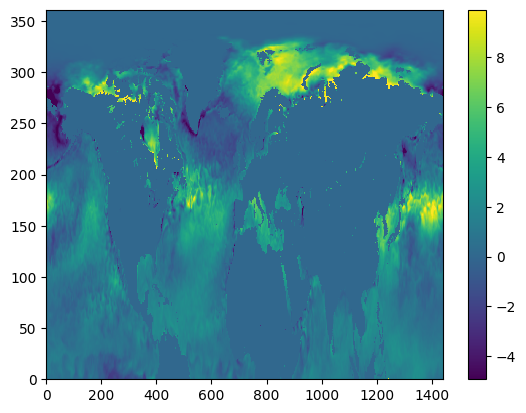

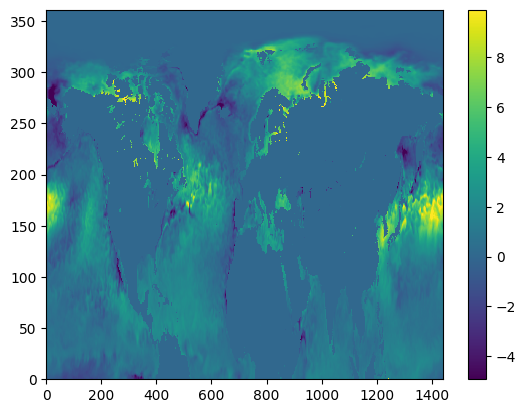

In [6]:
tensor = instnc['hist_sst_6months']
for i in tensor: 
    plt.pcolormesh(i)
    plt.colorbar()
    plt.show()

In [10]:
np.where(tensor > 9)

(array([0, 0, 0, ..., 5, 5, 5], shape=(4191,)),
 array([  0, 161, 161, ..., 174, 174, 174], shape=(4191,)),
 array([1242, 1304, 1305, ...,  531,  532,  533], shape=(4191,)))

In [8]:
total = sum(t.element_size() * t.nelement() for t in instnc.values())
print(f'{total / 1024**2:.1f} MB')

439.5 MB


In [6]:
request_weeks = patcher.Request('inm_swe', 0, 0,'20210101', 360, 91, 17, 1, 7, 1)
request_days = patcher.Request('inm_swe', 0, 0,'20210101', 360, 91, 120, 1, 1, 1)

tensors = patcher.load(patcher_context, [request_weeks, request_days])
for tensor in tensors: 
    print(torch.isnan(tensor).any(dim=(-2,-1))[0])


tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False])
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
      

#### **Normalize**

In [5]:
from scripts.utils import compute_norm
import json
import os

smpl_sz = 4096
reservoir = len(train_ds) * smpl_sz

stats = compute_norm(dataset=train_ds, 
                     reservoir=reservoir, 
                     sampl_sz=smpl_sz, 
                     out_path=f'database/norms/{train_ds.name}')


100%|██████████| 24/24 [00:03<00:00,  7.34it/s]


#### **Save on disk**

In [5]:
from scripts.utils import materialize_dataset

train_ds = ContiguousDataset(features=features, dates=train_dates, load_climate=load_climate, name = 'Contigous_Russia_Dataset')
test_ds = ContiguousDataset(features=features, dates=test_dates, load_climate=load_climate, name = 'Contigous_Russia_Dataset')

pth = f'/Users/a1/Desktop/arpp/dborisov/database/cached/{train_ds.name}'
materialize_dataset(train_ds, f'{pth}/train', pool_ensemble=True)
materialize_dataset(test_ds,  f'{pth}/test',  pool_ensemble=True)


 load climate keys: ['hist_sd_log_6weeks', 'hist_sd_log_6months', 'hist_sden_6weeks', 'hist_sden_6months', 'inm_ww_log_17weeks', 'target_sd_log_17weeks'] 



 NORMED DATASET:<_io.TextIOWrapper name='database/norms/Contigous_Russia_Dataset/Contigous_Russia_Dataset.json' mode='r' encoding='utf-8'>



 load climate keys: ['hist_sd_log_6weeks', 'hist_sd_log_6months', 'hist_sden_6weeks', 'hist_sden_6months', 'inm_ww_log_17weeks', 'target_sd_log_17weeks'] 



 NORMED DATASET:<_io.TextIOWrapper name='database/norms/Contigous_Russia_Dataset/Contigous_Russia_Dataset.json' mode='r' encoding='utf-8'>




materialize: 100%|██████████| 18/18 [00:47<00:00,  2.65s/it]


PosixPath('/Users/a1/Desktop/arpp/dborisov/database/cached/Contigous_Russia_Dataset/test')